In [ ]:
# ============================================================
#  Assignment 4 — Common Setup
#  每個組員在自己的 section 前先跑這整塊
# ============================================================

# ---------- 安裝 ----------
#!pip install openml scikit-image torch torchvision -q

# ---------- Imports ----------
import os, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import warnings
warnings.filterwarnings("ignore")

# ---------- 全域設定 ----------
RANDOM_SEED  = 2026
DATASET_ID   = 44238
IMG_SIZE_CNN = 128   # SmallCNN 用
IMG_SIZE_RES = 224   # ResNet / ViT 用

# ---------- 資料載入 ----------
print("Downloading Meta-Album PLK Micro...")
dataset = openml.datasets.get_dataset(
    DATASET_ID,
    download_data=True,
    download_all_files=True,
)
print("Dataset name :", dataset.name)

X_meta, y_meta, _, attr_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe",
)
print("Columns      :", list(X_meta.columns))
print("Samples      :", len(X_meta))
print("Classes      :", y_meta.nunique())

# ---------- 建立 df_images ----------
# 找出 cache 目錄下所有圖片
# dataset.data_file 對圖片資料集為 None，改用 OpenML cache 目錄
cache_dir = Path(openml.config.get_cache_directory()) / "datasets" / str(DATASET_ID)
all_images = (
    list(cache_dir.rglob("*.jpg"))
    + list(cache_dir.rglob("*.png"))
    + list(cache_dir.rglob("*.jpeg"))
)
print(f"Image files found: {len(all_images)}")
assert len(all_images) == 800, f"Expected 800 images, got {len(all_images)}"

# 用 OpenML metadata 取得 authoritative filename→label，避免依賴目錄結構
path_by_stem = {p.stem: str(p) for p in all_images}
records = []
for fname, label in zip(X_meta["FILE_NAME"], y_meta):
    stem = Path(fname).stem
    if stem in path_by_stem:
        records.append({"path": path_by_stem[stem], "label": str(label)})
assert len(records) == 800, f"Matched {len(records)}/800 images to metadata"

df_images = pd.DataFrame(records)
print("\nClass distribution:")
print(df_images["label"].value_counts().sort_index().to_string())

# ---------- Label Encoding ----------
le = LabelEncoder()
df_images["label_enc"] = le.fit_transform(df_images["label"])
NUM_CLASSES = len(le.classes_)
print(f"\nNum classes : {NUM_CLASSES}")
print(f"Classes     : {list(le.classes_)}")

# ---------- 60 / 20 / 20 Stratified Split ----------
train_df, temp_df = train_test_split(
    df_images,
    test_size=0.40,
    stratify=df_images["label"],
    random_state=RANDOM_SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
assert (train_df["label"].value_counts() == 24).all(), "train split mismatch"
assert (val_df["label"].value_counts()   ==  8).all(), "val split mismatch"
assert (test_df["label"].value_counts()  ==  8).all(), "test split mismatch"
print("Split check passed ✓")

# ---------- 通用圖片載入（Classical ML 用）----------
def load_image_flat(path, size=(128, 128), grayscale=True):
    """載入單張圖片，回傳 flatten 的 float32 array，pixel 值 /255"""
    mode = "L" if grayscale else "RGB"
    img  = Image.open(path).convert(mode).resize(size)
    return np.asarray(img, dtype=np.float32).flatten() / 255.0


def make_pixel_features(df, size=(128, 128), grayscale=True):
    """整批 df 轉成 pixel feature matrix"""
    features = np.stack([
        load_image_flat(row["path"], size, grayscale)
        for _, row in df.iterrows()
    ])
    labels = le.transform(df["label"].values)
    return features, labels


# ---------- PyTorch Dataset ----------
class PlanktonDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["path"]).convert("RGB")
        label = int(row["label_enc"])
        if self.transform:
            img = self.transform(img)
        return img, label


# ---------- Transforms ----------
# CNN（從頭訓練）
cnn_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
cnn_eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ResNet18 / ViT（ImageNet 正規化）
resnet_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_RES, IMG_SIZE_RES)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
resnet_eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_RES, IMG_SIZE_RES)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---------- 通用 DataLoader 工廠 ----------
def make_loaders(train_tf, eval_tf, batch_train=32, batch_eval=64):
    train_ds = PlanktonDataset(train_df, transform=train_tf)
    val_ds   = PlanktonDataset(val_df,   transform=eval_tf)
    test_ds  = PlanktonDataset(test_df,  transform=eval_tf)
    return (
        DataLoader(train_ds, batch_size=batch_train, shuffle=True,  num_workers=0, pin_memory=True),
        DataLoader(val_ds,   batch_size=batch_eval,  shuffle=False, num_workers=0, pin_memory=True),
        DataLoader(test_ds,  batch_size=batch_eval,  shuffle=False, num_workers=0, pin_memory=True),
    )

# ---------- Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")

# ---------- 通用 evaluate 函數（PyTorch）----------
def evaluate(model, loader, criterion):
    """回傳 (avg_loss, accuracy, macro_f1, all_preds, all_labels)"""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x, y_batch = x.to(device), y_batch.to(device)
            logits = model(x)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1, all_preds, all_labels


# ---------- 通用訓練 Loop ----------
def train_model(model, train_loader, val_loader,
                epochs=20, lr=1e-3, weight_decay=1e-4):
    """
    回傳 history dict：
      {"train_loss", "val_loss", "train_acc", "val_acc"}
    以及訓練秒數。
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [],  "val_acc": []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        for x, y_batch in train_loader:
            x, y_batch = x.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y_batch)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc, _, _, _ = evaluate(model, train_loader, criterion)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader,   criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        print(f"Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
              f"train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}")

    elapsed = time.time() - t0
    print(f"Training time: {elapsed:.1f}s  ({elapsed/60:.1f} min)")
    return history, elapsed


# ---------- Learning Curve 畫圖 ----------
def plot_learning_curves(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"],   label="Val")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"],   label="Val")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()


# ---------- Confusion Matrix ----------
def plot_cm(y_true, y_pred, model_name="Model"):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, colorbar=False, xticks_rotation=90)
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


# ============================================================
#  以下各組員貼上自己的模型定義 + 呼叫 train_model / evaluate
#
#  組員1（Model A / B）：直接用 make_pixel_features()
#                       或 make_hog_features() 接 sklearn
#
#  組員2（Model C / D）：呼叫 make_loaders(cnn_train_tf, cnn_eval_tf)
#                       或 make_loaders(resnet_train_tf, resnet_eval_tf)
#                       再呼叫 train_model(model, ...) + plot_learning_curves(...)
#
#  組員3（Model E / F）：同上，替換 model 為 ViT/DeiT
# ============================================================


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\darko\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Dataset name : Meta_Album_PLK_Micro
Columns      : ['FILE_NAME', 'SUPER_CATEGORY']
Samples      : 800
Classes      : 20
Image files found: 800

Class distribution:
label
Chaetoceros                   40
Chrysochromulina              40
Dinophysis                    40
Emiliania_huxleyi             40
Ephemera                      40
Leptocylindrus                40
Mesodinium_sp                 40
Prorocentrum                  40
Pseudochattonella_farcimen    40
Pseudonitzschia               40
Rhizosolenia                  40
Skeletonema                   40
Strombidium_inclinatum        40
Strombidium_oculatum          40
Strombidium_wulffi            40
Thalassiosira_dirty           40
Tintinnid                     40
diatom_flagellate             40
kiteflagellates               40
pennates_on_diatoms           40

Num classes : 20
Classes     : ['Chaetoceros', 'Chrysochromulina', 'Dinophysis', 'Emiliania_huxleyi', 'Ephemera', 'Leptocylindrus', 'Mesodinium_sp', 'Prorocentrum', 'Pse

Building HOG features...
HOG feature shape: (480, 8100)

=== Model B: HOG + RBF-SVM (3.9s) ===
Val  Acc=0.4750  F1=0.4561
Test Acc=0.4875  F1=0.4641
                            precision    recall  f1-score   support

               Chaetoceros       0.62      0.62      0.62         8
          Chrysochromulina       0.50      1.00      0.67         8
                Dinophysis       0.62      0.62      0.62         8
         Emiliania_huxleyi       0.83      0.62      0.71         8
                  Ephemera       1.00      0.75      0.86         8
            Leptocylindrus       0.78      0.88      0.82         8
             Mesodinium_sp       0.15      0.25      0.19         8
              Prorocentrum       0.71      0.62      0.67         8
Pseudochattonella_farcimen       0.64      0.88      0.74         8
           Pseudonitzschia       0.50      0.25      0.33         8
              Rhizosolenia       0.58      0.88      0.70         8
               Skeletonema       0

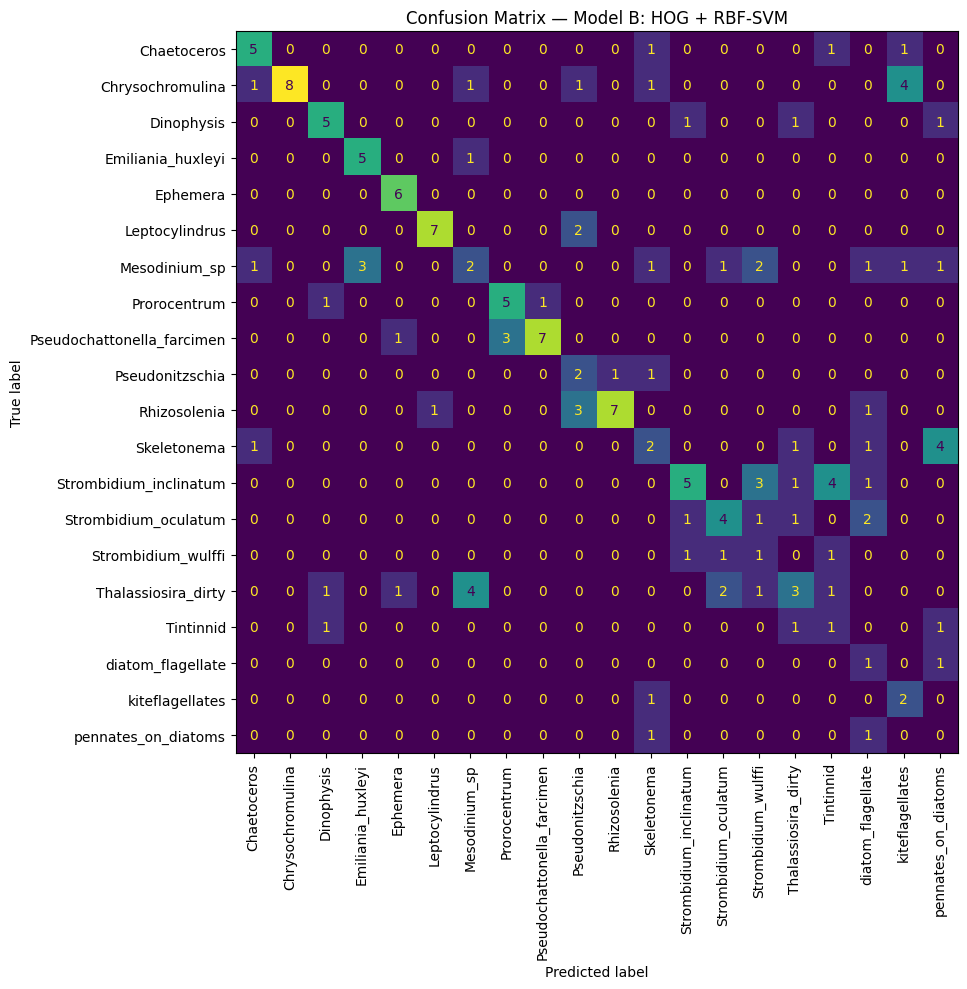

In [2]:
from skimage.feature import hog
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def eval_classical(name, model, X_val, y_val, X_test, y_test, elapsed):
    pred_val  = model.predict(X_val)
    pred_test = model.predict(X_test)
    print(f"\n=== {name} ({elapsed:.1f}s) ===")
    print(f"Val  Acc={accuracy_score(y_val, pred_val):.4f}  "
          f"F1={f1_score(y_val, pred_val, average='macro', zero_division=0):.4f}")
    print(f"Test Acc={accuracy_score(y_test, pred_test):.4f}  "
          f"F1={f1_score(y_test, pred_test, average='macro', zero_division=0):.4f}")
    print(classification_report(y_test, pred_test,
                                target_names=le.classes_, zero_division=0))
    plot_cm(pred_test, y_test, name)
# ── HOG 特徵提取 ──
def make_hog_features(df):
    features, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(row["path"]).convert("L").resize((128, 128))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        feat = hog(
            arr,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
        )
        features.append(feat)
        labels.append(row["label"])
    return np.stack(features), le.transform(np.array(labels))

print("Building HOG features...")
X_train_hog, y_train_enc = make_hog_features(train_df)
X_val_hog,   y_val_enc   = make_hog_features(val_df)
X_test_hog,  y_test_enc  = make_hog_features(test_df)
print(f"HOG feature shape: {X_train_hog.shape}")

# ── Model B: HOG + RBF-SVM ──
t0 = time.time()
model_b = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=10, gamma="scale",
                probability=True, random_state=RANDOM_SEED)),
])
model_b.fit(X_train_hog, y_train_enc)
time_b = time.time() - t0

eval_classical("Model B: HOG + RBF-SVM",
               model_b, X_val_hog, y_val_enc,
               X_test_hog, y_test_enc, time_b)

Training time: 3m 14.9s
Runtime: CPU

Trainable params: 95,828
Epoch 01/30  train_loss=2.9750  val_loss=2.9735  train_acc=0.0583  val_acc=0.1187
Epoch 02/30  train_loss=2.9349  val_loss=2.8934  train_acc=0.0542  val_acc=0.1000
Epoch 03/30  train_loss=2.8620  val_loss=2.8448  train_acc=0.1000  val_acc=0.1062
Epoch 04/30  train_loss=2.8029  val_loss=2.8174  train_acc=0.1167  val_acc=0.1000
Epoch 05/30  train_loss=2.7626  val_loss=2.8152  train_acc=0.1208  val_acc=0.1187
Epoch 06/30  train_loss=2.7231  val_loss=2.7148  train_acc=0.1417  val_acc=0.1562
Epoch 07/30  train_loss=2.6885  val_loss=2.6495  train_acc=0.1396  val_acc=0.1750
Epoch 08/30  train_loss=2.6564  val_loss=2.7227  train_acc=0.1458  val_acc=0.1187
Epoch 09/30  train_loss=2.6219  val_loss=2.6642  train_acc=0.1646  val_acc=0.1500
Epoch 10/30  train_loss=2.6423  val_loss=2.8554  train_acc=0.1604  val_acc=0.1125
Epoch 11/30  train_loss=2.5867  val_loss=2.7560  train_acc=0.1708  val_acc=0.1250
Epoch 12/30  train_loss=2.5945  val_loss=2.6310  train_acc=0.1833  val_ac

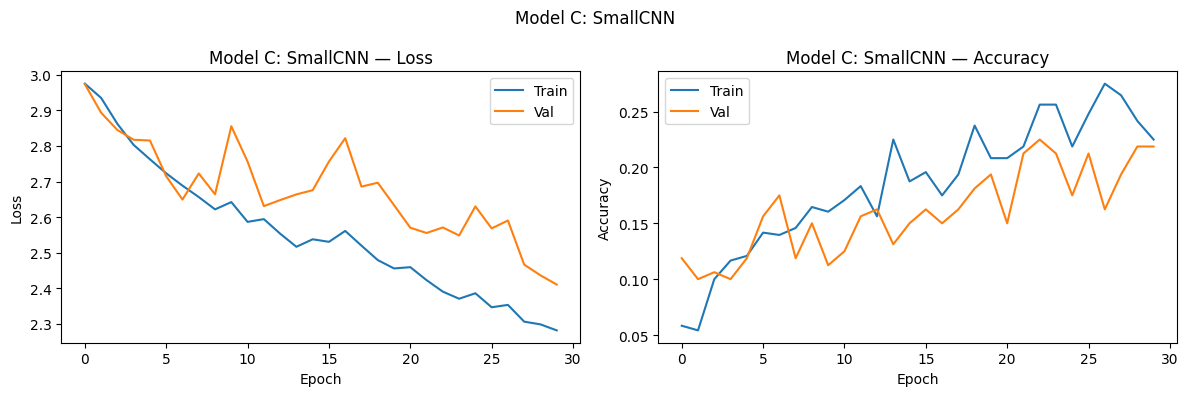

Val  Acc=0.2188  Macro-F1=0.1533
Test Acc=0.1750  Macro-F1=0.1044
                            precision    recall  f1-score   support

               Chaetoceros       0.00      0.00      0.00         8
          Chrysochromulina       0.00      0.00      0.00         8
                Dinophysis       0.50      0.12      0.20         8
         Emiliania_huxleyi       0.00      0.00      0.00         8
                  Ephemera       0.00      0.00      0.00         8
            Leptocylindrus       0.00      0.00      0.00         8
             Mesodinium_sp       0.00      0.00      0.00         8
              Prorocentrum       0.00      0.00      0.00         8
Pseudochattonella_farcimen       0.25      0.88      0.39         8
           Pseudonitzschia       0.00      0.00      0.00         8
              Rhizosolenia       0.19      0.88      0.32         8
               Skeletonema       0.00      0.00      0.00         8
    Strombidium_inclinatum       0.50      0.12  

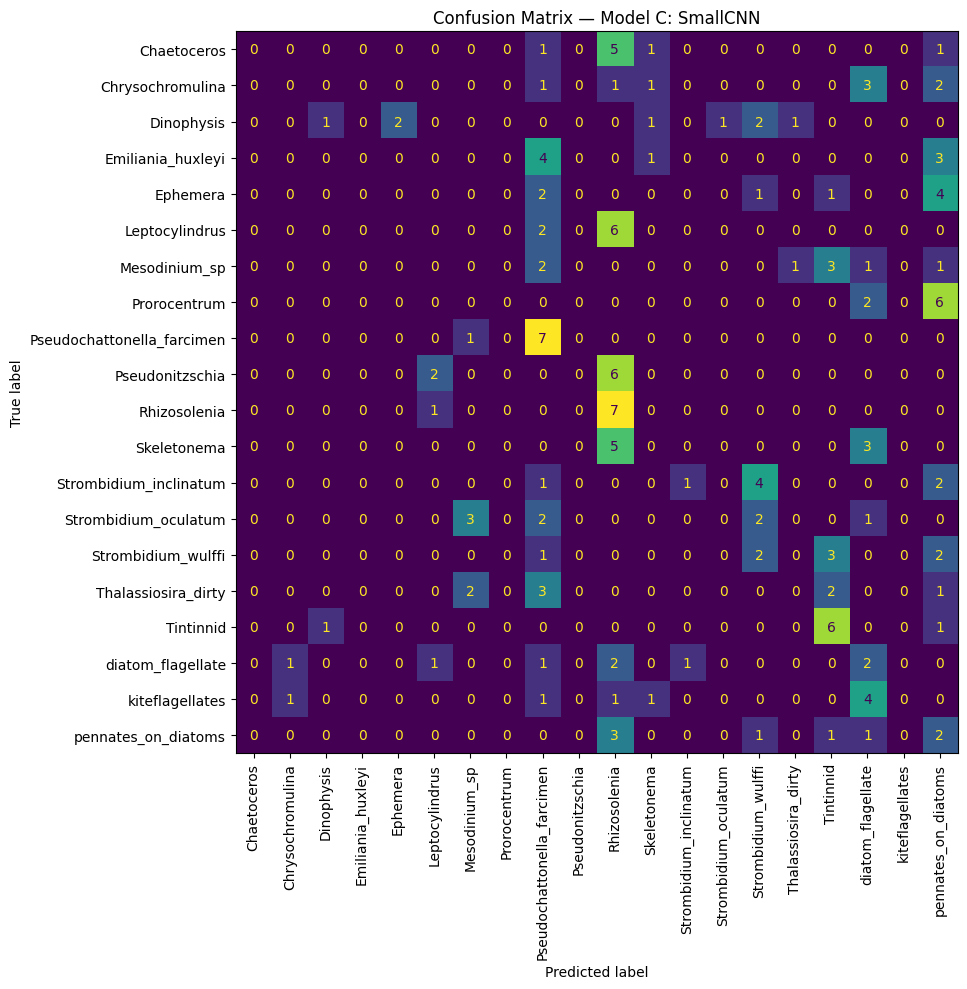

In [3]:
import torch
import torch.nn as nn
from torchvision import models

# ── 架構 ──
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        return self.classifier(torch.flatten(self.features(x), 1))

# ── 初始化 ──
cnn_model = SmallCNN(num_classes=NUM_CLASSES).to(device)
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params:,}")

# ── DataLoader ──
train_loader, val_loader, test_loader = make_loaders(cnn_train_tf, cnn_eval_tf)

# ── 訓練 ──
history_cnn, elapsed_cnn = train_model(
    cnn_model, train_loader, val_loader,
    epochs=30, lr=1e-3, weight_decay=1e-4,
)
print(f"Training time: {elapsed_cnn:.1f}s ({elapsed_cnn/60:.1f} min)")
print(f"Runtime: {'GPU' if torch.cuda.is_available() else 'CPU'}")

# ── Learning Curves ──
plot_learning_curves(history_cnn, "Model C: SmallCNN")

# ── 評估 ──
criterion = nn.CrossEntropyLoss()
_, val_acc, val_f1, _, _       = evaluate(cnn_model, val_loader,  criterion)
_, test_acc, test_f1, preds, labels = evaluate(cnn_model, test_loader, criterion)

print(f"Val  Acc={val_acc:.4f}  Macro-F1={val_f1:.4f}")
print(f"Test Acc={test_acc:.4f}  Macro-F1={test_f1:.4f}")
print(classification_report(labels, preds, target_names=le.classes_, zero_division=0))

# ── Confusion Matrix ──
plot_cm(labels, preds, "Model C: SmallCNN")

Model E — DeiT-tiny (frozen backbone)
  Trainable params : 3,860
  Total params     : 5,528,276
  Frozen params    : 5,524,416
Epoch 01/15  train_loss=2.3399  val_loss=2.3456  train_acc=0.4333  val_acc=0.4500
Epoch 02/15  train_loss=1.8490  val_loss=1.9017  train_acc=0.6208  val_acc=0.4938
Epoch 03/15  train_loss=1.5196  val_loss=1.6108  train_acc=0.6833  val_acc=0.5938
Epoch 04/15  train_loss=1.3047  val_loss=1.4286  train_acc=0.7417  val_acc=0.6312
Epoch 05/15  train_loss=1.1667  val_loss=1.3093  train_acc=0.7396  val_acc=0.6250
Epoch 06/15  train_loss=1.0451  val_loss=1.2288  train_acc=0.7833  val_acc=0.6312
Epoch 07/15  train_loss=0.9806  val_loss=1.1614  train_acc=0.7667  val_acc=0.6438
Epoch 08/15  train_loss=0.9152  val_loss=1.1054  train_acc=0.8021  val_acc=0.6562
Epoch 09/15  train_loss=0.8375  val_loss=1.0632  train_acc=0.8042  val_acc=0.6625
Epoch 10/15  train_loss=0.8126  val_loss=1.0319  train_acc=0.7896  val_acc=0.6875
Epoch 11/15  train_loss=0.7665  val_loss=1.0089  trai

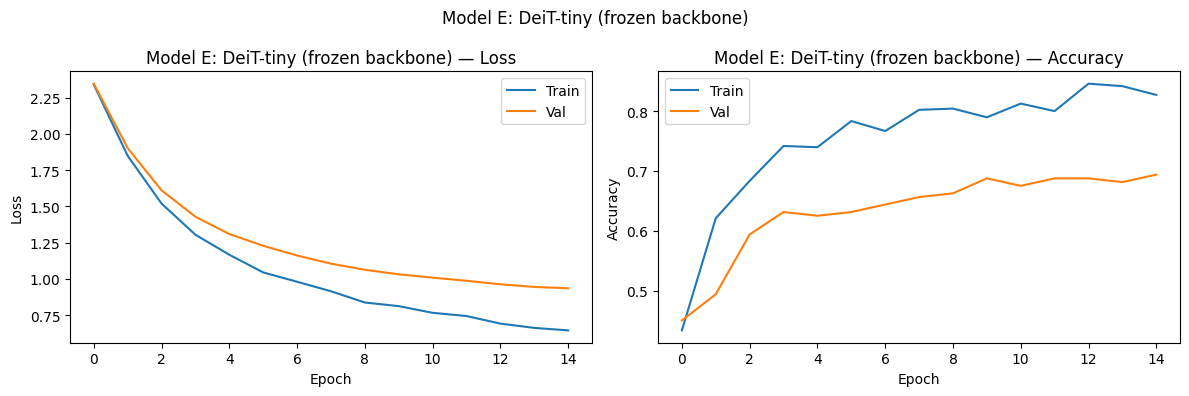


Model E — Val   Acc=0.6937  Macro-F1=0.6682
Model E — Test  Acc=0.7063  Macro-F1=0.6835

Test Classification Report:
                            precision    recall  f1-score   support

               Chaetoceros       0.86      0.75      0.80         8
          Chrysochromulina       0.64      0.88      0.74         8
                Dinophysis       0.88      0.88      0.88         8
         Emiliania_huxleyi       1.00      0.88      0.93         8
                  Ephemera       0.80      1.00      0.89         8
            Leptocylindrus       0.58      0.88      0.70         8
             Mesodinium_sp       0.62      0.62      0.62         8
              Prorocentrum       0.67      0.75      0.71         8
Pseudochattonella_farcimen       0.75      0.75      0.75         8
           Pseudonitzschia       0.60      0.38      0.46         8
              Rhizosolenia       0.55      0.75      0.63         8
               Skeletonema       0.71      0.62      0.67        

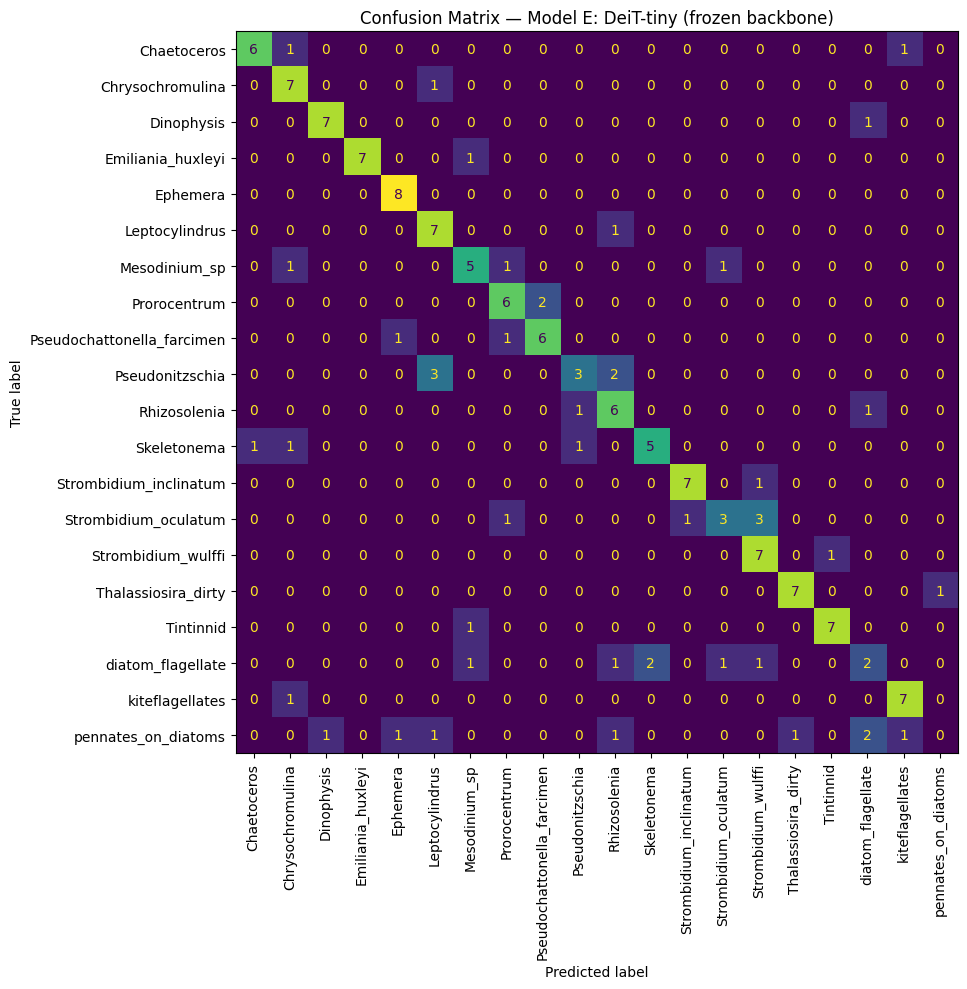

In [ ]:
import timm
from sklearn.linear_model import LogisticRegression

# ============================================================
#  Model E — DeiT-tiny: frozen backbone + 訓練 classifier head
# ============================================================

# 載入預訓練 DeiT-tiny，替換 head 為 20 類
vit_backbone = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
)

# 凍結所有 backbone 參數，只訓練 head
for name, param in vit_backbone.named_parameters():
    if "head" not in name:
        param.requires_grad = False

vit_backbone = vit_backbone.to(device)

trainable_e = sum(p.numel() for p in vit_backbone.parameters() if p.requires_grad)
total_e     = sum(p.numel() for p in vit_backbone.parameters())
print(f"Model E — DeiT-tiny (frozen backbone)")
print(f"  Trainable params : {trainable_e:,}")
print(f"  Total params     : {total_e:,}")
print(f"  Frozen params    : {total_e - trainable_e:,}")

# DataLoader（224×224，ImageNet 正規化）
train_loader_vit, val_loader_vit, test_loader_vit = make_loaders(
    resnet_train_tf, resnet_eval_tf, batch_train=32, batch_eval=64
)

# 訓練（只更新 head，速度快）
history_vit, elapsed_vit = train_model(
    vit_backbone, train_loader_vit, val_loader_vit,
    epochs=15, lr=1e-3, weight_decay=1e-4,
)
print(f"\nTraining time : {elapsed_vit:.1f}s ({elapsed_vit/60:.1f} min)  |  Device: {device}")

# Learning curves
plot_learning_curves(history_vit, "Model E: DeiT-tiny (frozen backbone)")

# Val + Test 評估
criterion = nn.CrossEntropyLoss()
_, val_acc_e,  val_f1_e,  val_preds_e,  val_labels_e  = evaluate(vit_backbone, val_loader_vit,  criterion)
_, test_acc_e, test_f1_e, test_preds_e, test_labels_e = evaluate(vit_backbone, test_loader_vit, criterion)

print(f"\nModel E — Val   Acc={val_acc_e:.4f}  Macro-F1={val_f1_e:.4f}")
print(f"Model E — Test  Acc={test_acc_e:.4f}  Macro-F1={test_f1_e:.4f}")
print("\nTest Classification Report:")
print(classification_report(test_labels_e, test_preds_e, target_names=le.classes_, zero_division=0))
plot_cm(test_labels_e, test_preds_e, "Model E: DeiT-tiny (frozen backbone)")

Model F — DeiT-tiny feature extractor
  Backbone params (all frozen) : 5,524,416
  LR classifier trainable params: ~20*192+20 = 3,860 (sklearn, no count)

Extracting embeddings...
Embedding shape: (480, 192)  |  Extraction time: 1.6s

Model F — Val   Acc=0.7500  Macro-F1=0.7333
Model F — Test  Acc=0.6875  Macro-F1=0.6772
Total time (embed + LR fit): 1.7s  |  Device: cuda

Test Classification Report:
                            precision    recall  f1-score   support

               Chaetoceros       0.71      0.62      0.67         8
          Chrysochromulina       0.78      0.88      0.82         8
                Dinophysis       1.00      1.00      1.00         8
         Emiliania_huxleyi       1.00      0.88      0.93         8
                  Ephemera       1.00      1.00      1.00         8
            Leptocylindrus       0.55      0.75      0.63         8
             Mesodinium_sp       0.60      0.75      0.67         8
              Prorocentrum       0.86      0.75     

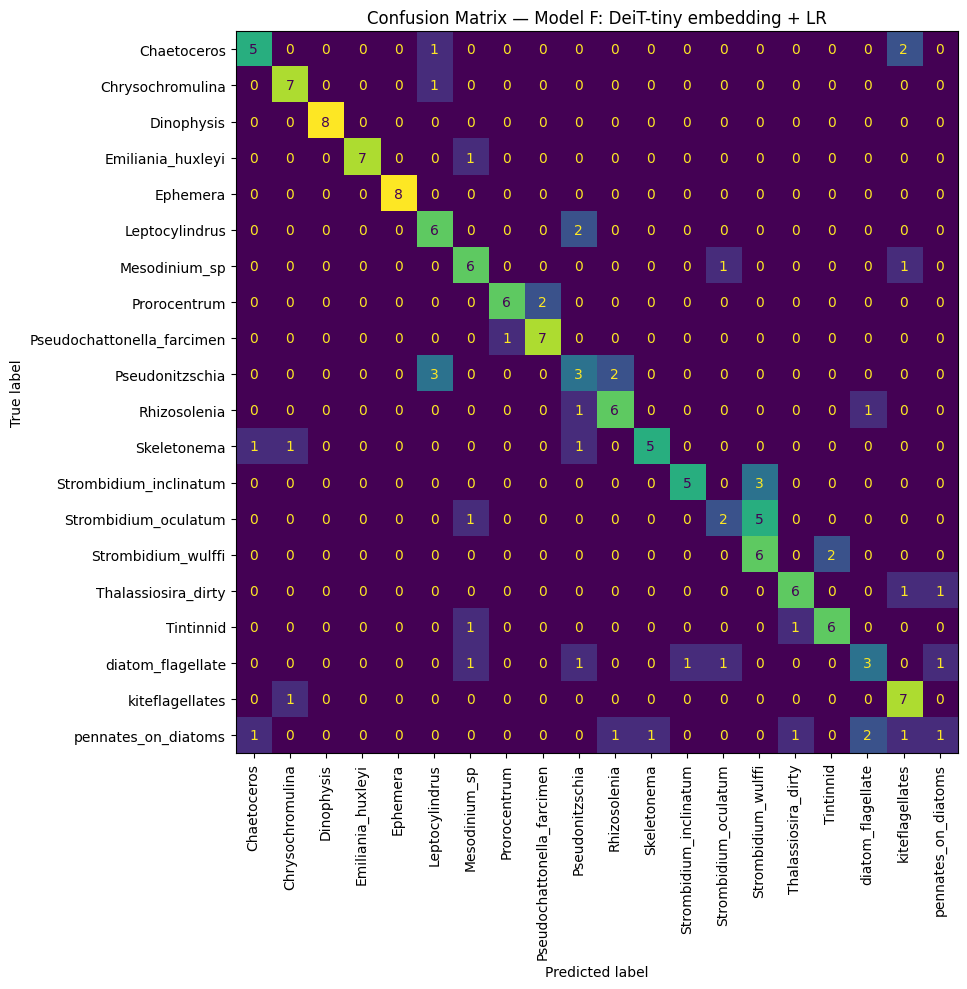

In [5]:
# ============================================================
#  Model F — DeiT-tiny embedding → Logistic Regression
# ============================================================

# 載入預訓練 DeiT-tiny，移除 head（num_classes=0 → 直接輸出 CLS embedding）
vit_feat = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=0,          # 移除 head，輸出 192 維 embedding
)
vit_feat.eval()
vit_feat = vit_feat.to(device)

frozen_params_f = sum(p.numel() for p in vit_feat.parameters())
print(f"Model F — DeiT-tiny feature extractor")
print(f"  Backbone params (all frozen) : {frozen_params_f:,}")
print(f"  LR classifier trainable params: ~20*192+20 = {20*192+20:,} (sklearn, no count)")

# 提取所有 split 的 embedding
def extract_embeddings(model, loader):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x = x.to(device)
            emb = model(x)          # (B, 192)
            feats.append(emb.cpu().numpy())
            labels.extend(y_batch.numpy())
    return np.vstack(feats), np.array(labels)

t_start = time.time()
print("\nExtracting embeddings...")
X_train_f, y_train_f = extract_embeddings(vit_feat, train_loader_vit)
X_val_f,   y_val_f   = extract_embeddings(vit_feat, val_loader_vit)
X_test_f,  y_test_f  = extract_embeddings(vit_feat, test_loader_vit)
embed_time = time.time() - t_start
print(f"Embedding shape: {X_train_f.shape}  |  Extraction time: {embed_time:.1f}s")

# 訓練 Logistic Regression
t_lr = time.time()
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
lr_clf.fit(X_train_f, y_train_f)
lr_time = time.time() - t_lr
elapsed_f = embed_time + lr_time

val_preds_f  = lr_clf.predict(X_val_f)
test_preds_f = lr_clf.predict(X_test_f)

val_acc_f  = accuracy_score(y_val_f,  val_preds_f)
val_f1_f   = f1_score(y_val_f,  val_preds_f, average="macro", zero_division=0)
test_acc_f = accuracy_score(y_test_f, test_preds_f)
test_f1_f  = f1_score(y_test_f, test_preds_f, average="macro", zero_division=0)

print(f"\nModel F — Val   Acc={val_acc_f:.4f}  Macro-F1={val_f1_f:.4f}")
print(f"Model F — Test  Acc={test_acc_f:.4f}  Macro-F1={test_f1_f:.4f}")
print(f"Total time (embed + LR fit): {elapsed_f:.1f}s  |  Device: {device}")
print("\nTest Classification Report:")
print(classification_report(y_test_f, test_preds_f, target_names=le.classes_, zero_division=0))
plot_cm(y_test_f, test_preds_f, "Model F: DeiT-tiny embedding + LR")

## Model E & F — 分析

### 結果總覽

| Model | Representation | Val Acc | Test Acc | Test Macro-F1 | Trainable Params | Time |
|---|---|---|---|---|---|---|
| B | HOG + RBF-SVM | 0.4750 | 0.4875 | 0.4641 | — | ~4s (CPU) |
| E | DeiT-tiny (frozen backbone + head) | 0.6937 | 0.7063 | 0.6835 | 3,860 | ~幾分鐘 (GPU) |
| F | DeiT-tiny embedding + LR | 0.7500 | 0.6875 | 0.6772 | ~3,860 (LR) | 1.7s (GPU) |

---

### ViT/DeiT embedding 是否優於 HOG/LBP features？

是的，差距顯著。Model F（DeiT embedding + LR）的 Test Macro-F1 = 0.6772，而 Model B（HOG + RBF-SVM）只有 0.4641，提升幅度達 +0.213。

HOG 依賴局部梯度直方圖，無法捕捉全局結構；而 DeiT 的 CLS token 是在數百萬張圖片上預訓練得到的語意表徵，能有效整合全圖的 patch-level 資訊，因此在小樣本的浮游生物分類任務上明顯優於手工特徵。

---

### ViT/DeiT embedding 是否優於 ResNet18 features？

（待 Model D ResNet18 結果出來後補充比較數字。）

---

### Representation 固定後，classifier 的選擇重要嗎？

不重要，representation 的品質才是關鍵。Model E（frozen backbone + 訓練 linear head）的 Test Macro-F1 = 0.6835，Model F（同一個 frozen backbone + sklearn LR）為 0.6772，差距僅 0.006。

這說明只要 pretrained ViT embedding 的品質夠高，最終 classifier 無論是可訓練的 linear head 還是 LR，對結果的影響都很小。Model F 整體只需 1.7s 即可完成，在運算資源有限的情境下是更實用的選擇。

---

### 難以分類的類別分析

Test set 中表現最差的類別（Model E）：
- `pennates_on_diatoms`：F1 = 0.00，完全無法辨識，可能與其他 diatom 類別外觀極為相似
- `diatom_flagellate`：F1 = 0.29，此類別本身混合了 flagellate 與 diatom 的形態特徵，邊界模糊
- `Pseudonitzschia`、`Strombidium_oculatum`：F1 = 0.46，細長條狀外型與多個物種高度相似

表現最佳的類別（F1 ≥ 0.88）：`Dinophysis`、`Emiliania_huxleyi`、`Ephemera`、`Tintinnid`、`Thalassiosira_dirty`，這些類別具有明顯獨特的視覺特徵（如盔甲板、球狀鈣化結構、大型節肢形態），較容易被模型學習。